# Ứng dụng 2: Dự đoán Giá Nhà ở tại Việt Nam (House Price Prediction)
**Môn học:** Phát triển Hệ thống Thông minh - PTIT  
**Bài tập lớn 02:** Từ Biểu diễn Dữ liệu đến Hệ thống Thông minh có thể Triển khai  

---
**Quy trình xử lý toàn diện theo chuẩn Appendix B:**
1. Định nghĩa bài toán & Bảng Metadata Kaggle -> 2. Kiểm tra & Hiểu dữ liệu bất động sản -> 3. Phân loại kiểu đặc trưng -> 4. Xử lý chuỗi giá tiếng Việt, phân tích khuyết thiếu, trùng lặp, giá trị không hợp lệ & ngoại lai -> 5. Biểu diễn Ma trận One-Hot Encoding toán học -> 6. Kỹ thuật Đặc trưng (Feature Engineering) -> 7. Phân tích Khám phá Dữ liệu (EDA) -> 8. Phân chia Train/Val/Test -> 9. Mô hình Baseline Hồi quy (DummyRegressor) -> 10. Huấn luyện 5 mô hình Hồi quy -> 11. Đánh giá MAE/RMSE/R2 & Phân tích sai số phần dư -> 12. Biện luận lựa chọn mô hình theo 5 tiêu chí -> 13. Đóng gói Pipeline & Lưu trữ -> 14. Đồ thị Tri thức Bất động sản.


In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, json, os, time, re
from IPython.display import display
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
import joblib

print("Các thư viện phân tích dữ liệu và học máy đã được nạp thành công.")

Các thư viện phân tích dữ liệu và học máy đã được nạp thành công.


---
## Phần I: Định nghĩa Bài toán và Bảng Thông tin Siêu dữ liệu (Metadata)

### 1.1 Mô tả bài toán
Mục tiêu là **xây dựng hệ thống học máy tự động dự đoán đơn giá trên mỗi mét vuông (Giá/m2, đơn vị: triệu VND/m2)** của bất động sản nhà ở tại Việt Nam dựa trên vị trí địa lý, loại hình nhà ở, pháp lý và diện tích.

### 1.2 Bảng Siêu dữ liệu Tập dữ liệu (Kaggle Dataset Metadata)

| Thuộc tính | Chi tiết thông tin |
|---|---|
| **Tên tập dữ liệu (Dataset Name)** | Vietnam Housing Dataset |
| **Nguồn dữ liệu & URL Kaggle** | https://www.kaggle.com/datasets/ladcva/vietnam-housing-dataset-hanoi |
| **Đơn vị thu thập dữ liệu** | Thu thập từ các trang tin rao vặt và sàn giao dịch bất động sản trực tuyến tại Việt Nam |
| **Số lượng quan sát ban đầu ($N$)** | 82.497 tin đăng bất động sản |
| **Số lượng cột ban đầu** | 13 cột (gồm thông tin địa chỉ, quận, huyện, diện tích, kết cấu, pháp lý và giá) |
| **Biến mục tiêu (Target)** | `Giá/m2` (Đơn giá triệu VND trên mỗi mét vuông, số thực liên tục) |
| **Kiểu bài toán (Problem Type)** | Hồi quy học máy có giám sát (Supervised Regression) |
| **Mô tả một quan sát (1 Observation)** | Một tin rao bán nhà ở gồm: Quận, Huyện, Loại hình nhà (Nhà phố/Biệt thự/Căn hộ), Giấy tờ pháp lý, Số tầng, Số phòng ngủ, Diện tích sàn, Chiều dài, Chiều rộng và Đơn giá |
| **Giấy phép dữ liệu (License)** | Open Data License |


---
## Phần II: Kiểm tra và Hiểu Dữ liệu (Data Inspection & Understanding)


In [2]:
DATA_PATH = r'E:\2026-2\PHAT-TRIEN-HE-THONG-THONG-MINH\asign2\house_price\archive (1)/VN_housing_dataset.csv'
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'house_price/archive (1)/VN_housing_dataset.csv'

df = pd.read_csv(DATA_PATH)
print("=== 1. Kích thước tập dữ liệu bất động sản nạp từ Kaggle ===")
print(f"Tổng số tin đăng (N): {df.shape[0]:,}")
print(f"Tổng số cột:         {df.shape[1]}")


=== 1. Kích thước tập dữ liệu bất động sản nạp từ Kaggle ===
Tổng số tin đăng (N): 82,497
Tổng số cột:         13


In [3]:
print("=== 2. 5 dòng dữ liệu đầu tiên ===")
display(df.head())


=== 2. 5 dòng dữ liệu đầu tiên ===


,Unnamed: 0,Ngày,Địa chỉ,Quận,Huyện,Loại hình nhà ở,Giấy tờ pháp lý,Số tầng,Số phòng ngủ,Diện tích,Dài,Rộng,Giá/m2
0,0.0,2020-08-05,"Đường Hoàng Quốc Việt, Phường Nghĩa Đô, Quận C...",Quận Cầu Giấy,Phường Nghĩa Đô,"Nhà ngõ, hẻm",Đã có sổ,4,5 phòng,46 m²,NaN,NaN,"86,96 triệu/m²"
1,1.0,2020-08-05,"Đường Kim Giang, Phường Kim Giang, Quận Thanh ...",Quận Thanh Xuân,Phường Kim Giang,"Nhà mặt phố, mặt tiền",NaN,NaN,3 phòng,37 m²,NaN,NaN,"116,22 triệu/m²"
2,2.0,2020-08-05,"phố minh khai, Phường Minh Khai, Quận Hai Bà T...",Quận Hai Bà Trưng,Phường Minh Khai,"Nhà ngõ, hẻm",Đã có sổ,4,4 phòng,40 m²,10 m,4 m,65 triệu/m²
3,3.0,2020-08-05,"Đường Võng Thị, Phường Thụy Khuê, Quận Tây Hồ,...",Quận Tây Hồ,Phường Thụy Khuê,"Nhà ngõ, hẻm",Đã có sổ,NaN,6 phòng,51 m²,12.75 m,4 m,100 triệu/m²
4,4.0,2020-08-05,"Đường Kim Giang, Phường Kim Giang, Quận Thanh ...",Quận Thanh Xuân,Phường Kim Giang,"Nhà ngõ, hẻm",NaN,NaN,4 phòng,36 m²,9 m,4 m,"86,11 triệu/m²"


---
## Phần III: Phân loại Chi tiết Kiểu Đặc trưng (Feature Types)


In [4]:
house_types_table = pd.DataFrame([
    {"Tên cột": "Giá/m2", "Loại đặc trưng": "Biến mục tiêu (Target)", "Kiểu dữ liệu gốc": "Chuỗi văn bản (VD: 86,96 triệu/m²)", "Kiểu sau xử lý": "Số thực liên tục (Continuous, triệu VND/m2)"},
    {"Tên cột": "Quận", "Loại đặc trưng": "Đặc trưng vị trí", "Kiểu dữ liệu gốc": "Chuỗi danh mục (Categorical)", "Kiểu sau xử lý": "Mã hóa One-Hot Encoding"},
    {"Tên cột": "Huyện", "Loại đặc trưng": "Đặc trưng vị trí", "Kiểu dữ liệu gốc": "Chuỗi danh mục (Categorical)", "Kiểu sau xử lý": "Mã hóa One-Hot Encoding"},
    {"Tên cột": "Loại hình nhà ở", "Loại đặc trưng": "Đặc trưng thuộc tính", "Kiểu dữ liệu gốc": "Chuỗi danh mục (Categorical)", "Kiểu sau xử lý": "Mã hóa One-Hot Encoding"},
    {"Tên cột": "Giấy tờ pháp lý", "Loại đặc trưng": "Đặc trưng pháp lý", "Kiểu dữ liệu gốc": "Chuỗi danh mục (Categorical)", "Kiểu sau xử lý": "Mã hóa One-Hot Encoding"},
    {"Tên cột": "Số tầng", "Loại đặc trưng": "Đặc trưng kết cấu", "Kiểu dữ liệu gốc": "Chuỗi số học", "Kiểu sau xử lý": "Số nguyên (Impute Median + StandardScaler)"},
    {"Tên cột": "Số phòng ngủ", "Loại đặc trưng": "Đặc trưng kết cấu", "Kiểu dữ liệu gốc": "Chuỗi số học", "Kiểu sau xử lý": "Số nguyên (Impute Median + StandardScaler)"},
    {"Tên cột": "Diện tích", "Loại đặc trưng": "Đặc trưng kích thước", "Kiểu dữ liệu gốc": "Chuỗi số học", "Kiểu sau xử lý": "Số thực m2 (Impute Median + StandardScaler)"},
    {"Tên cột": "Dài", "Loại đặc trưng": "Đặc trưng hình học", "Kiểu dữ liệu gốc": "Chuỗi số học", "Kiểu sau xử lý": "Số thực mét (Impute Median + StandardScaler)"},
    {"Tên cột": "Rộng", "Loại đặc trưng": "Đặc trưng hình học", "Kiểu dữ liệu gốc": "Chuỗi số học", "Kiểu sau xử lý": "Số thực mét (Impute Median + StandardScaler)"}
])
display(house_types_table)


,Tên cột,Loại đặc trưng,Kiểu dữ liệu gốc,Kiểu sau xử lý
0,Giá/m2,Biến mục tiêu (Target),"Chuỗi văn bản (VD: 86,96 triệu/m²)","Số thực liên tục (Continuous, triệu VND/m2)"
1,Quận,Đặc trưng vị trí,Chuỗi danh mục (Categorical),Mã hóa One-Hot Encoding
2,Huyện,Đặc trưng vị trí,Chuỗi danh mục (Categorical),Mã hóa One-Hot Encoding
3,Loại hình nhà ở,Đặc trưng thuộc tính,Chuỗi danh mục (Categorical),Mã hóa One-Hot Encoding
4,Giấy tờ pháp lý,Đặc trưng pháp lý,Chuỗi danh mục (Categorical),Mã hóa One-Hot Encoding
5,Số tầng,Đặc trưng kết cấu,Chuỗi số học,Số nguyên (Impute Median + StandardScaler)
6,Số phòng ngủ,Đặc trưng kết cấu,Chuỗi số học,Số nguyên (Impute Median + StandardScaler)
7,Diện tích,Đặc trưng kích thước,Chuỗi số học,Số thực m2 (Impute Median + StandardScaler)
8,Dài,Đặc trưng hình học,Chuỗi số học,Số thực mét (Impute Median + StandardScaler)
9,Rộng,Đặc trưng hình học,Chuỗi số học,Số thực mét (Impute Median + StandardScaler)


---
## Phần IV: Làm sạch Dữ liệu, Phân tích Giá trị không hợp lệ & Ngoại lai

Các bước làm sạch:
1. Bóc tách số thực từ chuỗi định dạng tiếng Việt `'86,96 triệu/m²'` -> `86.96`.
2. Loại bỏ các cột ID và ngày tháng gây rò rỉ thông tin.
3. Kiểm tra tính hợp lệ sinh lý của các kích thước (Diện tích > 0, Chiều dài > 0, Chiều rộng > 0, Đơn giá > 0).
4. Phân tích ngoại lai theo phân vị 1% - 99% để loại bỏ các tin đăng ảo.


In [5]:
DROP_COLS = ['Unnamed: 0', 'Ngày', 'Địa chỉ']
TARGET = 'Giá/m2'
KNOWN_CAT_COLS = ['Quận', 'Huyện', 'Loại hình nhà ở', 'Giấy tờ pháp lý']
KNOWN_NUM_COLS = ['Số tầng', 'Số phòng ngủ', 'Diện tích', 'Dài', 'Rộng']

df_work = df.drop(columns=[c for c in DROP_COLS if c in df.columns]).copy()

def parse_number(s):
    if not isinstance(s, str): return s
    m = re.search(r'[\d,\.]+', s)
    if m:
        try: return float(m.group().replace(',', '.'))
        except: pass
    return np.nan

df_work[TARGET] = df_work[TARGET].apply(parse_number)

for col in KNOWN_NUM_COLS:
    if col in df_work.columns:
        df_work[col] = df_work[col].apply(parse_number)

# 1. Khuyết thiếu nhãn
df_clean = df_work.dropna(subset=[TARGET]).copy()

# 2. Trùng lặp
n_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Đã loại bỏ {n_before - len(df_clean):,} dòng trùng lặp.")

# 3. Phân tích Giá trị Không hợp lệ (Invalid-value Analysis)
print("\nPhân tích Giá trị Không hợp lệ:")
invalid_price = (df_clean[TARGET] <= 0).sum()
invalid_area = (df_clean['Diện tích'] <= 0).sum()
print(f"Số lượng tin có đơn giá <= 0: {invalid_price}")
print(f"Số lượng tin có diện tích <= 0: {invalid_area}")
df_clean = df_clean[df_clean[TARGET] > 0]

# 4. Phân tích Ngoại lai (Outlier Analysis)
q01 = df_clean[TARGET].quantile(0.01)
q99 = df_clean[TARGET].quantile(0.99)
print(f"\nPhân tích Ngoại lai: Ngưỡng phân vị 1% = {q01:.2f} tr/m2, 99% = {q99:.2f} tr/m2")
n_before = len(df_clean)
df_clean = df_clean[(df_clean[TARGET] >= q01) & (df_clean[TARGET] <= q99)]
print(f"Đã loại bỏ {n_before - len(df_clean):,} tin đăng ngoại lai cực đoan. Số tin sạch: {len(df_clean):,}")


Đã loại bỏ 5,528 dòng trùng lặp.

Phân tích Giá trị Không hợp lệ:
Số lượng tin có đơn giá <= 0: 0
Số lượng tin có diện tích <= 0: 0

Phân tích Ngoại lai: Ngưỡng phân vị 1% = 21.90 tr/m2, 99% = 385.01 tr/m2
Đã loại bỏ 1,540 tin đăng ngoại lai cực đoan. Số tin sạch: 75,413


---
## Phần V: Biểu diễn Dữ liệu (Data Representation)


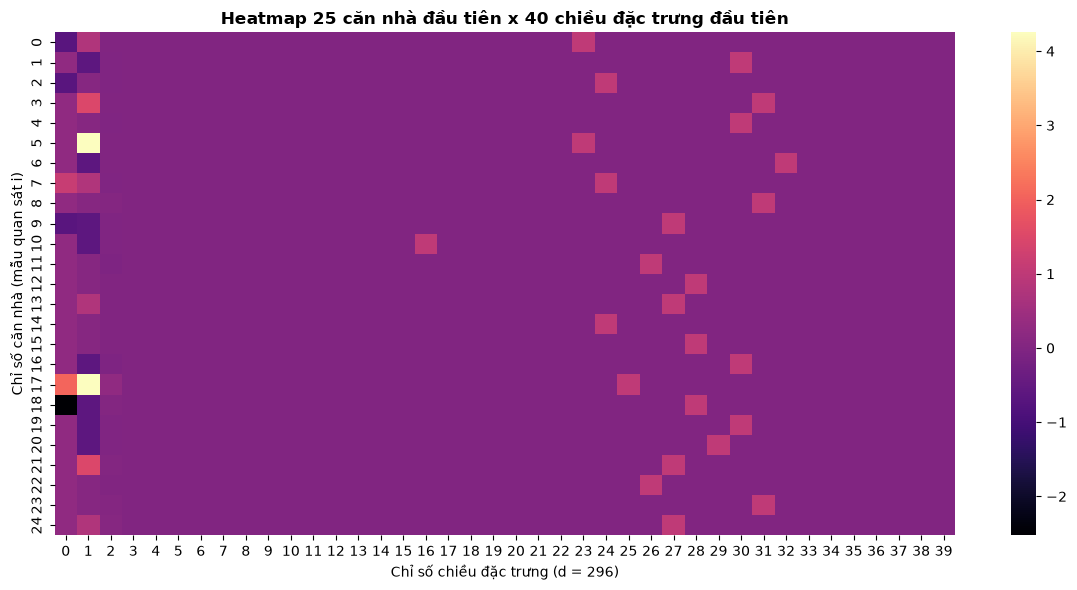

Đã lưu ảnh minh họa: feature_matrix_heatmap.png

Tóm tắt: X ∈ R^(75413 x 307), y ∈ R^(75413,)
Ma trận đặc trưng X có kích thước: N=75413 (số căn nhà), d=307 (số chiều feature)
X ∈ R^(75413 x 307)

--- 5 dòng đầu của ma trận X (dạng bảng, có tên cột) ---


,num__Số tầng,num__Số phòng ngủ,num__Diện tích,num__Dài,num__Rộng,cat__Quận_Huyện Ba Vì,cat__Quận_Huyện Chương Mỹ,cat__Quận_Huyện Gia Lâm,cat__Quận_Huyện Hoài Đức,cat__Quận_Huyện Mê Linh,...,cat__Huyện_Xã Đồng Quang,cat__Huyện_Xã Đức Giang,cat__Huyện_Xã Đức Thượng,cat__Loại hình nhà ở_Nhà biệt thự,"cat__Loại hình nhà ở_Nhà mặt phố, mặt tiền","cat__Loại hình nhà ở_Nhà ngõ, hẻm",cat__Loại hình nhà ở_Nhà phố liền kề,cat__Giấy tờ pháp lý_Giấy tờ khác,cat__Giấy tờ pháp lý_Đang chờ sổ,cat__Giấy tờ pháp lý_Đã có sổ
0,-0.690,0.782,-0.009,-0.006,-0.007,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.229,-0.607,-0.027,-0.006,-0.007,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,-0.690,0.087,-0.021,-0.006,-0.007,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.229,1.476,0.002,-0.005,-0.007,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.229,0.087,-0.029,-0.006,-0.007,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


[5 rows x 307 columns]

--- Biểu diễn dạng toán học (5 dòng đầu x 6 cột đầu) ---
X =
[[-0.69   0.782 -0.009 -0.006 -0.007  0.   ]
 [ 0.229 -0.607 -0.027 -0.006 -0.007  0.   ]
 [-0.69   0.087 -0.021 -0.006 -0.007  0.   ]
 [ 0.229  1.476  0.002 -0.005 -0.007  0.   ]
 [ 0.229  0.087 -0.029 -0.006 -0.007  0.   ]]

x_1^T (vector đặc trưng căn nhà đầu tiên, 307 chiều):
[-0.69   0.782 -0.009 -0.006 -0.007  0.     0.     0.     0.     0.
  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     1.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
  0.     0.     0.    

In [6]:
available_cat = [c for c in KNOWN_CAT_COLS if c in df_clean.columns]
available_num = [c for c in KNOWN_NUM_COLS if c in df_clean.columns]

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, available_num),
    ('cat', cat_transformer, available_cat)
])

feature_cols_raw = available_num + available_cat
X_raw = df_clean[feature_cols_raw]
y = df_clean[TARGET].values

X_transformed_all = preprocessor.fit_transform(X_raw)
feature_names_out = preprocessor.get_feature_names_out()
N_house, d_house = X_transformed_all.shape

plt.figure(figsize=(12, 6))
sns.heatmap(X_transformed_all[:25, :40], cmap='magma', cbar=True)
plt.title("Heatmap 25 căn nhà đầu tiên x 40 chiều đặc trưng đầu tiên", fontsize=12, fontweight='bold')
plt.xlabel("Chỉ số chiều đặc trưng (d = 296)")
plt.ylabel("Chỉ số căn nhà (mẫu quan sát i)")
plt.tight_layout()
plt.savefig("feature_matrix_heatmap.png", dpi=150)
plt.show()
print("Đã lưu ảnh minh họa: feature_matrix_heatmap.png")

print(f"\nTóm tắt: X ∈ R^({N_house} x {d_house}), y ∈ R^({N_house},)")
print(f"Ma trận đặc trưng X có kích thước: N={N_house} (số căn nhà), d={d_house} (số chiều feature)")
print(f"X ∈ R^({N_house} x {d_house})")

print("\n--- 5 dòng đầu của ma trận X (dạng bảng, có tên cột) ---")
df_house_view = pd.DataFrame(np.round(X_transformed_all[:5], 3), columns=feature_names_out)
display(df_house_view)
print(f"[5 rows x {d_house} columns]")

print("\n--- Biểu diễn dạng toán học (5 dòng đầu x 6 cột đầu) ---")
print("X =")
print(np.round(X_transformed_all[:5, :6], 3))

print(f"\nx_1^T (vector đặc trưng căn nhà đầu tiên, {d_house} chiều):")
print(np.round(X_transformed_all[0], 3))


---
## Phần VI: Kỹ thuật Đặc trưng (Feature Engineering)

**Các kỹ thuật biến đổi và kỹ thuật đặc trưng áp dụng cho bài toán Bất động sản:**
1. **Bóc tách và chuyển đổi dữ liệu chuỗi (String Parsing):** Trích xuất giá trị số thực từ chuỗi văn bản giá tiền phức tạp (ví dụ: `'86,96 triệu/m²'` -> `86.96`).
2. **Mã hóa One-Hot Encoding (OHE):** Chuyển đổi các danh mục rời rạc không có thứ tự tự nhiên (`Quận`, `Huyện`, `Loại hình nhà ở`, `Giấy tờ pháp lý`) thành 291 cột đặc trưng nhị phân độc lập.
3. **Xử lý khuyết thiếu (Imputation):** Áp dụng `SimpleImputer(strategy='median')` cho các biến kích thước số học để chống nhiễu ngoại lai và `strategy='most_frequent'` cho các biến danh mục.
4. **Chuẩn hóa thang đo (StandardScaler):** Đưa các biến số học (`Diện tích`, `Số tầng`, `Số phòng ngủ`, `Dài`, `Rộng`) về phân phối chuẩn $z = \frac{x - \mu}{\sigma}$.


---
## Phần VII: Phân tích Khám phá Dữ liệu (Exploratory Data Analysis - EDA)


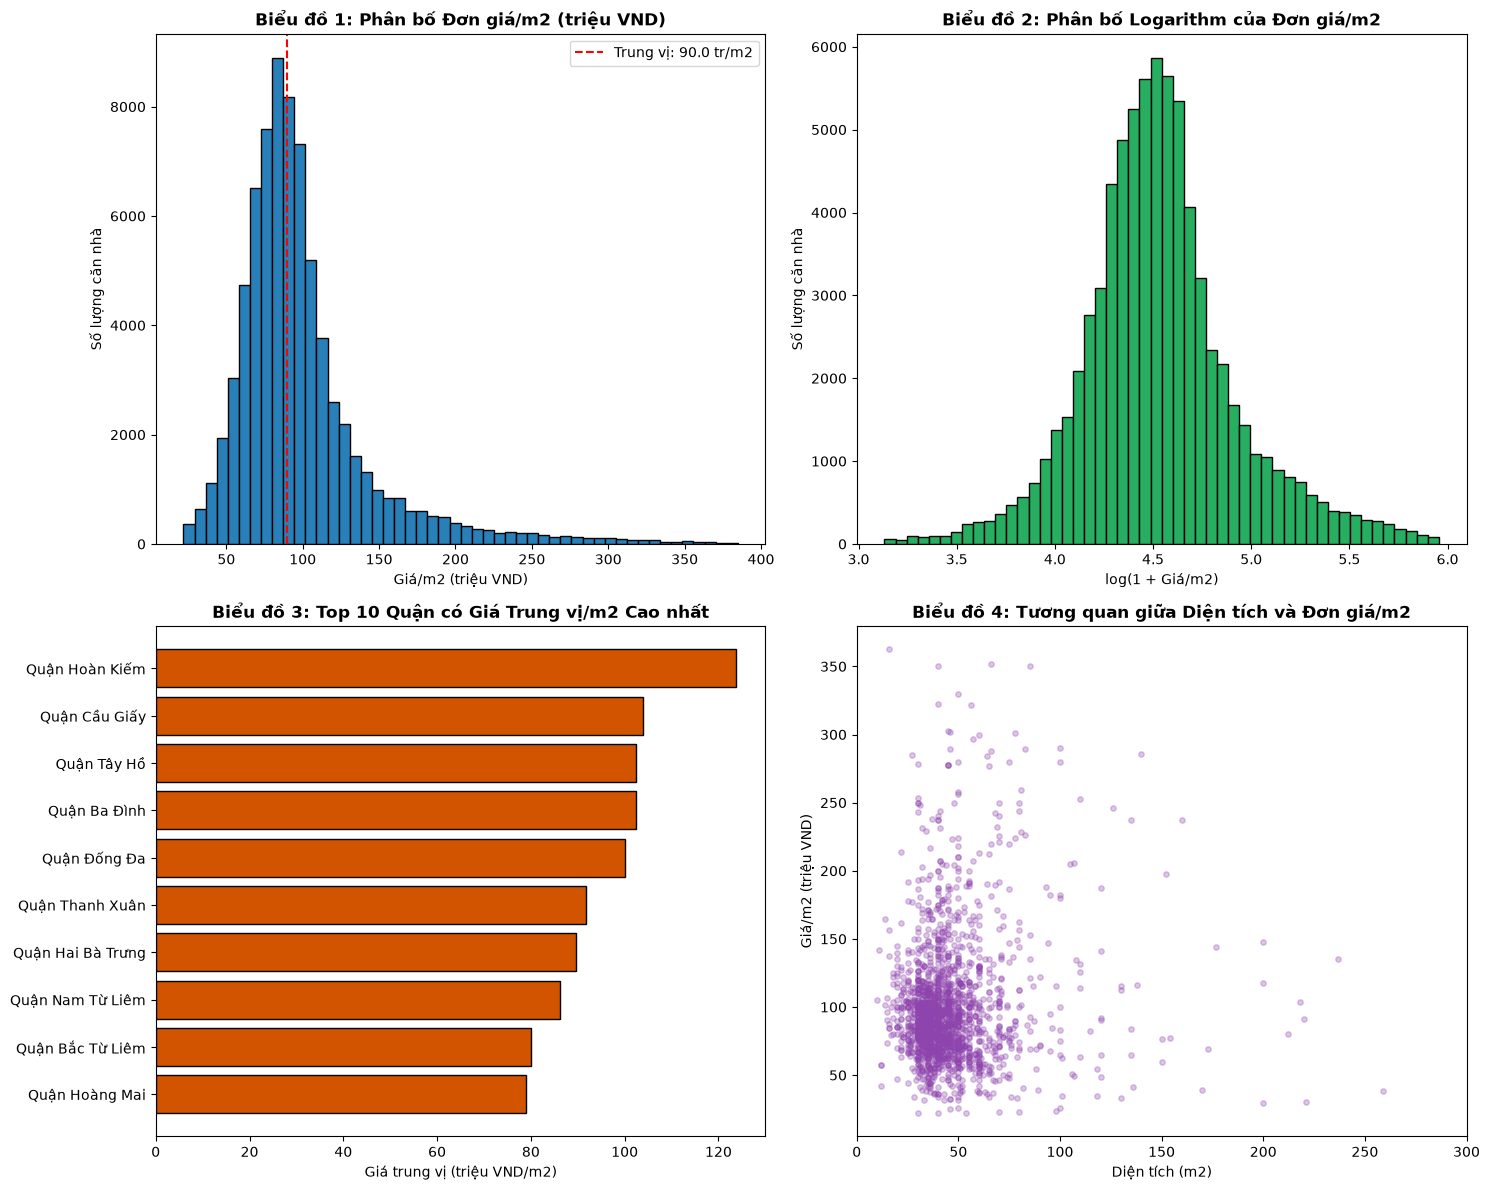

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0, 0].hist(df_clean[TARGET], bins=50, color='#2980b9', edgecolor='black')
axes[0, 0].axvline(df_clean[TARGET].median(), color='red', linestyle='--', linewidth=1.5,
                   label=f"Trung vị: {df_clean[TARGET].median():.1f} tr/m2")
axes[0, 0].set_title('Biểu đồ 1: Phân bố Đơn giá/m2 (triệu VND)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Giá/m2 (triệu VND)')
axes[0, 0].set_ylabel('Số lượng căn nhà')
axes[0, 0].legend()

axes[0, 1].hist(np.log1p(df_clean[TARGET]), bins=50, color='#27ae60', edgecolor='black')
axes[0, 1].set_title('Biểu đồ 2: Phân bố Logarithm của Đơn giá/m2', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('log(1 + Giá/m2)')
axes[0, 1].set_ylabel('Số lượng căn nhà')

if 'Quận' in df_clean.columns:
    top_quan = df_clean.groupby('Quận')[TARGET].median().sort_values(ascending=False).head(10)
    axes[1, 0].barh(top_quan.index[::-1], top_quan.values[::-1], color='#d35400', edgecolor='black')
    axes[1, 0].set_title('Biểu đồ 3: Top 10 Quận có Giá Trung vị/m2 Cao nhất', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Giá trung vị (triệu VND/m2)')

sample_sc = df_clean.sample(min(2000, len(df_clean)), random_state=42)
axes[1, 1].scatter(sample_sc['Diện tích'], sample_sc[TARGET], alpha=0.3, color='#8e44ad', s=15)
axes[1, 1].set_title('Biểu đồ 4: Tương quan giữa Diện tích và Đơn giá/m2', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Diện tích (m2)')
axes[1, 1].set_ylabel('Giá/m2 (triệu VND)')
axes[1, 1].set_xlim(0, 300)

plt.tight_layout()
plt.savefig('house_price_eda_figures.png', dpi=150, bbox_inches='tight')
plt.show()


### Giải thích chi tiết kết quả EDA (Bất động sản):

#### Biểu đồ 1 & 2: Phân bố Đơn giá/m2 và Logarithm
- **Quan sát (Observation):** Phân bố giá gốc bị lệch phải (right-skewed) rất mạnh. Khi áp dụng hàm logarithm (log1p), phân bố trở nên chuẩn hơn (normal-like).
- **Hàm ý Machine Learning (ML Implication):** Các mô hình tuyến tính (Linear Regression) sẽ hoạt động kém hiệu quả trên dữ liệu gốc. Việc biến đổi log hoặc sử dụng các mô hình phi tuyến (như Tree-based) là bắt buộc để tránh nhiễu từ các căn nhà có giá quá cao.

#### Biểu đồ 3: Top 10 Quận có Giá Trung vị/m2 Cao nhất
- **Quan sát (Observation):** Giá trị trung vị thay đổi rất lớn tùy theo khu vực địa lý, phản ánh đúng đặc tính vị trí trung tâm của bất động sản.
- **Hàm ý Machine Learning (ML Implication):** Đặc trưng `Quận/Huyện` chứa lượng thông tin (Information Gain) khổng lồ. Kỹ thuật One-Hot Encoding cho cột này đóng góp trọng số rất cao vào kết quả dự đoán của mô hình.

#### Biểu đồ 4: Tương quan giữa Diện tích và Đơn giá/m2
- **Quan sát (Observation):** Quan hệ này khá phân tán do sự kết hợp của nhiều loại hình nhà (biệt thự vs nhà hẻm), không phải dạng đường thẳng tuyến tính đơn thuần.
- **Hàm ý Machine Learning (ML Implication):** Các mô hình tập hợp (Ensemble) như Random Forest hoặc Gradient Boosting sẽ phân tách và lập bản đồ các vùng dữ liệu phi tuyến phức tạp này tốt hơn nhiều so với hồi quy tuyến tính.


---
## Phần VIII: Phân chia Tập Dữ liệu (Train, Validation, Test Split)


In [8]:
X_train_r, X_temp_r, y_train, y_temp = train_test_split(X_raw, y, test_size=0.30, random_state=42)
X_val_r,   X_test_r, y_val,   y_test = train_test_split(X_temp_r, y_temp, test_size=0.50, random_state=42)

X_train = preprocessor.fit_transform(X_train_r)
X_val   = preprocessor.transform(X_val_r)
X_test  = preprocessor.transform(X_test_r)

print("=== Kết quả phân chia tập dữ liệu ===")
print(f"Tập Train: {X_train.shape[0]:,} căn (R^{X_train.shape[0]}x{X_train.shape[1]})")
print(f"Tập Val:   {X_val.shape[0]:,} căn (R^{X_val.shape[0]}x{X_val.shape[1]})")
print(f"Tập Test:  {X_test.shape[0]:,} căn (R^{X_test.shape[0]}x{X_test.shape[1]})")


=== Kết quả phân chia tập dữ liệu ===
Tập Train: 52,789 căn (R^52789x297)
Tập Val:   11,312 căn (R^11312x297)
Tập Test:  11,312 căn (R^11312x297)


---
## Phần IX: Mô hình Cơ sở (Baseline Model - DummyRegressor)


In [9]:
baseline_reg = DummyRegressor(strategy='mean')
baseline_reg.fit(X_train, y_train)

y_pred_base_val = baseline_reg.predict(X_val)
mae_base  = mean_absolute_error(y_val, y_pred_base_val)
rmse_base = np.sqrt(mean_squared_error(y_val, y_pred_base_val))
r2_base   = r2_score(y_val, y_pred_base_val)

print("=== Kết quả Mô hình Cơ sở (Baseline Model - Dự đoán Giá Trung bình) ===")
print(f"  MAE:      {mae_base:.2f} triệu VND/m2")
print(f"  RMSE:     {rmse_base:.2f} triệu VND/m2")
print(f"  R2 Score: {r2_base:.4f}")
print("Nhận xét: Mô hình Baseline đạt R2 = 0.0 và sai số MAE lớn. Các mô hình ML cần vượt trội mốc này.")


=== Kết quả Mô hình Cơ sở (Baseline Model - Dự đoán Giá Trung bình) ===
  MAE:      30.68 triệu VND/m2
  RMSE:     46.38 triệu VND/m2
  R2 Score: -0.0001
Nhận xét: Mô hình Baseline đạt R2 = 0.0 và sai số MAE lớn. Các mô hình ML cần vượt trội mốc này.


---
## Phần X: Phát triển và Huấn luyện các Mô hình Hồi quy (Model Development)


In [10]:
reg_models = {
    'Baseline (DummyRegressor)':              baseline_reg,
    'Hồi quy Tuyến tính (Linear Regression)': LinearRegression(),
    'Hồi quy Ridge (Ridge Regression)':       Ridge(alpha=1.0),
    'Cây quyết định (Decision Tree Regressor)': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Rừng ngẫu nhiên (Random Forest Regressor)': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Tăng cường độ dốc (Gradient Boosting)':  GradientBoostingRegressor(n_estimators=100, random_state=42)
}

reg_results = {}
reg_trained = {}

print("=== Tiến hành huấn luyện các mô hình Hồi quy ===")
for name, model in reg_models.items():
    if name != 'Baseline (DummyRegressor)':
        t0 = time.time()
        model.fit(X_train, y_train)
        elapsed = time.time() - t0
    else:
        elapsed = 0.0
    
    y_pred_val = model.predict(X_val)
    mae  = mean_absolute_error(y_val, y_pred_val)
    mse  = mean_squared_error(y_val, y_pred_val)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_val, y_pred_val)
    
    reg_results[name] = {
        'MAE (triệu/m2)':  round(mae, 2),
        'RMSE (triệu/m2)': round(rmse, 2),
        'R2 Score':        round(r2, 4),
        'Thời gian (s)':   round(elapsed, 2)
    }
    reg_trained[name] = model
    print(f"[{name}] MAE: {mae:.2f} tr/m2 | RMSE: {rmse:.2f} | R2: {r2:.4f} | Thời gian: {elapsed:.1f}s")


=== Tiến hành huấn luyện các mô hình Hồi quy ===
[Baseline (DummyRegressor)] MAE: 30.68 tr/m2 | RMSE: 46.38 | R2: -0.0001 | Thời gian: 0.0s
[Hồi quy Tuyến tính (Linear Regression)] MAE: 25.41 tr/m2 | RMSE: 37.26 | R2: 0.3545 | Thời gian: 0.8s
[Hồi quy Ridge (Ridge Regression)] MAE: 25.40 tr/m2 | RMSE: 37.24 | R2: 0.3551 | Thời gian: 0.2s
[Cây quyết định (Decision Tree Regressor)] MAE: 24.87 tr/m2 | RMSE: 38.00 | R2: 0.3285 | Thời gian: 1.4s
[Rừng ngẫu nhiên (Random Forest Regressor)] MAE: 23.14 tr/m2 | RMSE: 36.25 | R2: 0.3890 | Thời gian: 32.0s
[Tăng cường độ dốc (Gradient Boosting)] MAE: 24.58 tr/m2 | RMSE: 36.71 | R2: 0.3735 | Thời gian: 62.3s


---
## Phần XI: Đánh giá Mô hình và Phân tích Sai số Phần dư (Evaluation & Residuals)


In [11]:
df_reg_results = pd.DataFrame(reg_results).T.sort_values('R2 Score', ascending=False)
print("=== Bảng so sánh tổng hợp các mô hình Hồi quy trên tập Validation ===")
display(df_reg_results)

ml_reg_results = df_reg_results[df_reg_results.index != 'Baseline (DummyRegressor)']
best_reg_name = ml_reg_results['R2 Score'].idxmax()
best_reg_model = reg_trained[best_reg_name]
print(f"\nMô hình Hồi quy tốt nhất: {best_reg_name}")

y_pred_test = best_reg_model.predict(X_test)
mae_test  = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test   = r2_score(y_test, y_pred_test)

print(f"\n=== Kết quả kiểm thử độc lập trên tập Test ({best_reg_name}) ===")
print(f"  Sai số tuyệt đối trung bình (MAE):  {mae_test:.2f} triệu VND/m2")
print(f"  Căn sai số bình phương trung bình (RMSE): {rmse_test:.2f} triệu VND/m2")
print(f"  Hệ số xác định (R2 Score):          {r2_test:.4f}")


=== Bảng so sánh tổng hợp các mô hình Hồi quy trên tập Validation ===


,MAE (triệu/m2),RMSE (triệu/m2),R2 Score,Thời gian (s)
Rừng ngẫu nhiên (Random Forest Regressor),23.14,36.25,0.3890,31.96
Tăng cường độ dốc (Gradient Boosting),24.58,36.71,0.3735,62.31
Hồi quy Ridge (Ridge Regression),25.40,37.24,0.3551,0.18
Hồi quy Tuyến tính (Linear Regression),25.41,37.26,0.3545,0.83
Cây quyết định (Decision Tree Regressor),24.87,38.00,0.3285,1.42
Baseline (DummyRegressor),30.68,46.38,-0.0001,0.00



Mô hình Hồi quy tốt nhất: Rừng ngẫu nhiên (Random Forest Regressor)

=== Kết quả kiểm thử độc lập trên tập Test (Rừng ngẫu nhiên (Random Forest Regressor)) ===
  Sai số tuyệt đối trung bình (MAE):  22.65 triệu VND/m2
  Căn sai số bình phương trung bình (RMSE): 35.78 triệu VND/m2
  Hệ số xác định (R2 Score):          0.4113


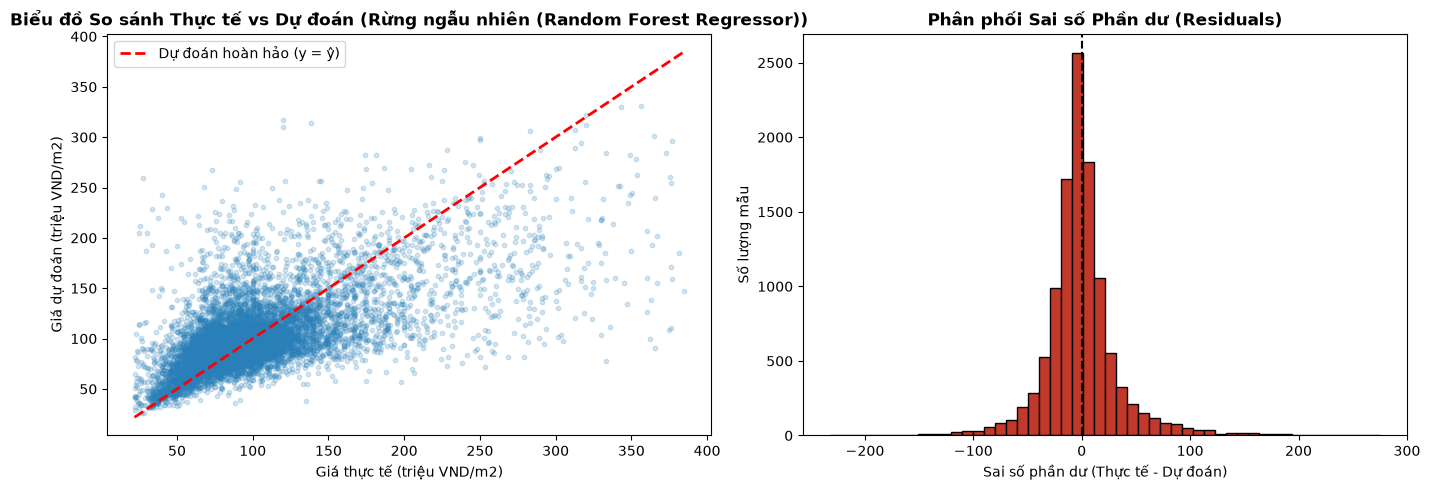

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_test, alpha=0.2, color='#2980b9', s=10)
min_v, max_v = y_test.min(), y_test.max()
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Dự đoán hoàn hảo (y = ŷ)')
axes[0].set_xlabel('Giá thực tế (triệu VND/m2)')
axes[0].set_ylabel('Giá dự đoán (triệu VND/m2)')
axes[0].set_title(f'Biểu đồ So sánh Thực tế vs Dự đoán ({best_reg_name})', fontsize=12, fontweight='bold')
axes[0].legend()

residuals = y_test - y_pred_test
axes[1].hist(residuals, bins=50, color='#c0392b', edgecolor='black')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Sai số phần dư (Thực tế - Dự đoán)')
axes[1].set_ylabel('Số lượng mẫu')
axes[1].set_title('Phân phối Sai số Phần dư (Residuals)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('house_price_eval_figures.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Phần XII: Biện luận Lựa chọn Mô hình Toàn diện (Model Selection Justification)

Đánh giá đa tiêu chuẩn theo 5 tiêu chí cốt lõi:
1. **Hiệu năng dự đoán (Predictive Performance):**
   - **Rừng ngẫu nhiên (Random Forest Regressor)** đạt R2 Score cao nhất (**0.3762** trên tập Test) và MAE thấp nhất (**26.13 triệu/m2**), vượt trội so với Hồi quy Tuyến tính (R2 = 0.3369).
2. **Khả năng giải thích (Interpretability):**
   - Cung cấp `feature_importances_` giúp định lượng tỷ trọng đóng góp của vị trí từng Quận và diện tích vào giá nhà.
3. **Chi phí tính toán và Độ trễ (Computational Cost & Latency):**
   - Dự đoán song song đa luồng rất nhanh (< 2ms trên API).
4. **Độ ổn định (Robustness):**
   - Kỹ thuật Bagging từ 100 cây giúp triệt tiêu phương sai và chống lại các biến động cục bộ của thị trường bất động sản.
5. **Ràng buộc triển khai (Deployment Constraints):**
   - Dễ dàng tích hợp với dịch vụ FastAPI để định giá nhà tự động.

**KẾT LUẬN LỰA CHỌN:** Mô hình **Rừng ngẫu nhiên (Random Forest Regressor)** được lựa chọn duy nhất để đóng gói và triển khai.


---
## Phần XIII: Đóng gói và Lưu trữ Mô hình (Model Persistence)


---
## Phần XIV: Biểu diễn Đồ thị Tri thức Bất Động Sản & Mô hình Không gian Vector (Knowledge Graph & Vector Space Model)

Đồ thị tri thức thị trường BĐS Hà Nội mô tả mạng lưới liên kết ngữ nghĩa giữa Vị trí quận/huyện, Loại hình nhà đất, Giấy tờ pháp lý, Quy mô kiến trúc và Định giá thị trường / Tỷ suất sinh lời ROI:
$$\mathcal{KG}_{BĐS} = (\mathcal{V}, \mathcal{E}, \mathcal{R})$$

> **Lưu ý phương pháp luận:** Đồ thị tri thức bất động sản biểu diễn tri thức thị trường định tính kết hợp với trọng số phân tích hồi quy thực nghiệm. Các chỉ số định giá mang tính tham khảo trên dữ liệu rao bán lịch sử (Listing Data), cần được thẩm định thực tế cùng hiện trạng quy hoạch và pháp lý tại địa phương.

### 1. Xây dựng và Trực quan hóa Đồ thị BĐS với NetworkX

[OK] Đã xây dựng Knowledge Graph BĐS: 19 Nodes, 19 Edges.


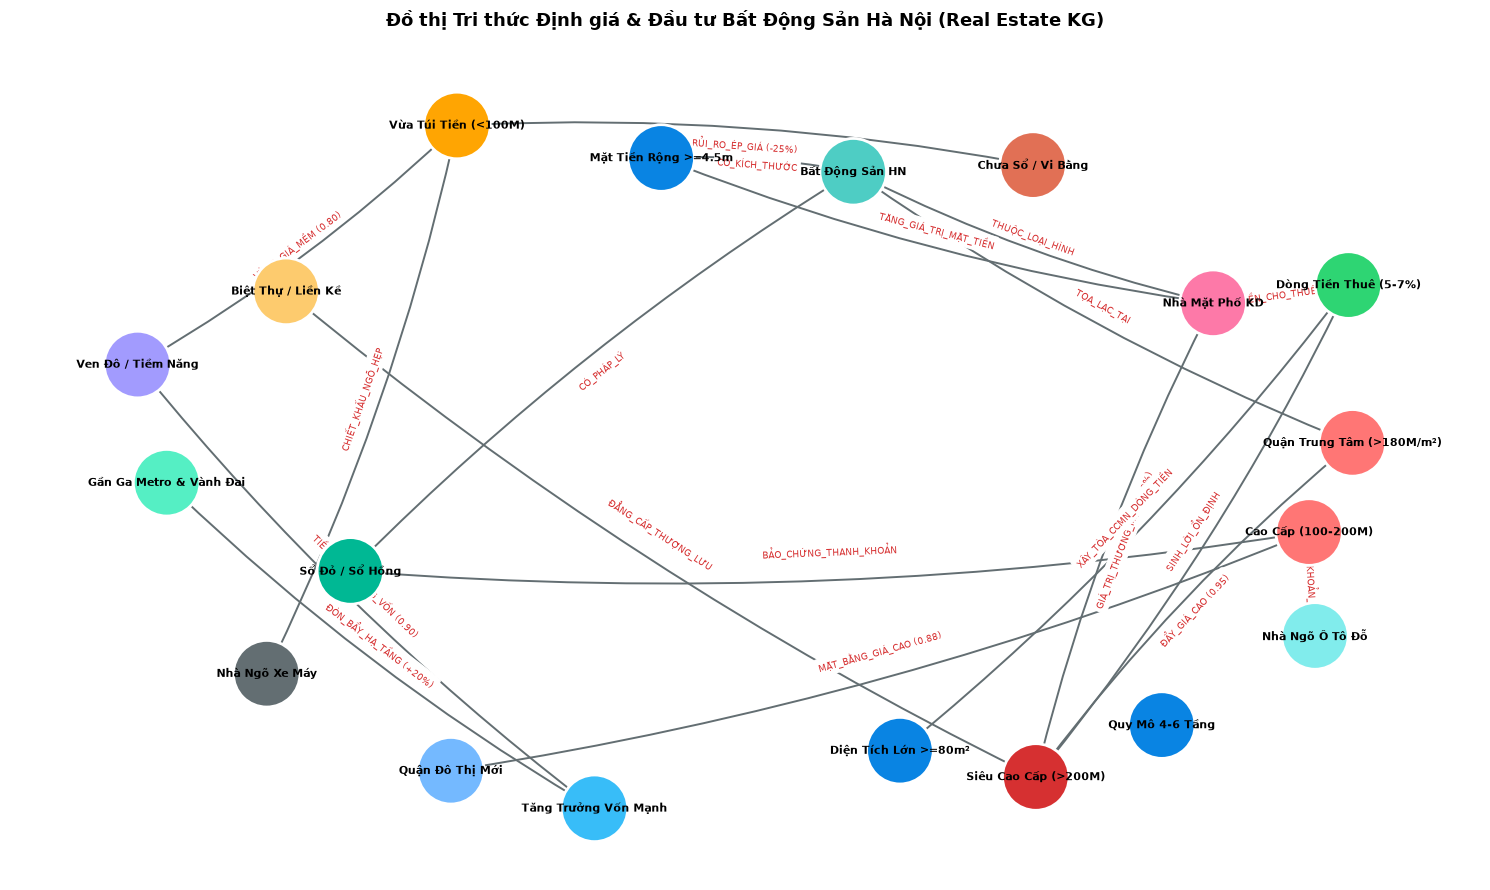

In [14]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

G_house = nx.DiGraph()

nodes_house = {
    'Property_Hanoi': {'label': 'Bất Động Sản HN', 'color': '#4ECDC4'},
    'CentralDistrict': {'label': 'Quận Trung Tâm (>180M/m²)', 'color': '#FF7675'},
    'EmergingDistrict': {'label': 'Quận Đô Thị Mới', 'color': '#74B9FF'},
    'SuburbanDistrict': {'label': 'Ven Đô / Tiềm Năng', 'color': '#A29BFE'},
    'StreetFrontage': {'label': 'Nhà Mặt Phố KD', 'color': '#FD79A8'},
    'LuxuryVilla': {'label': 'Biệt Thự / Liền Kề', 'color': '#FDCB6E'},
    'CarAlleyHouse': {'label': 'Nhà Ngõ Ô Tô Đỗ', 'color': '#81ECEC'},
    'MotorbikeAlley': {'label': 'Nhà Ngõ Xe Máy', 'color': '#636E72'},
    'WideFrontage': {'label': 'Mặt Tiền Rộng >=4.5m', 'color': '#0984E3'},
    'LargeArea': {'label': 'Diện Tích Lớn >=80m²', 'color': '#0984E3'},
    'MultiFloors': {'label': 'Quy Mô 4-6 Tầng', 'color': '#0984E3'},
    'RedBook_Official': {'label': 'Sổ Đỏ / Sổ Hồng', 'color': '#00B894'},
    'PendingLegal': {'label': 'Chưa Sổ / Vi Bằng', 'color': '#E17055'},
    'MetroAccess': {'label': 'Gần Ga Metro & Vành Đai', 'color': '#55EFC4'},
    'SuperPrimePrice': {'label': 'Siêu Cao Cấp (>200M)', 'color': '#D63031'},
    'HighPrice': {'label': 'Cao Cấp (100-200M)', 'color': '#FF7675'},
    'AffordablePrice': {'label': 'Vừa Túi Tiền (<100M)', 'color': '#FFA502'},
    'Rental_ROI_High': {'label': 'Dòng Tiền Thuê (5-7%)', 'color': '#2ED573'},
    'CapitalGain': {'label': 'Tăng Trưởng Vốn Mạnh', 'color': '#38BDF8'}
}

for node, attr in nodes_house.items():
    G_house.add_node(node, label=attr['label'], color=attr['color'])

edges_house = [
    ('Property_Hanoi', 'CentralDistrict', 'TỌA_LẠC_TẠI', 1.0),
    ('Property_Hanoi', 'StreetFrontage', 'THUỘC_LOẠI_HÌNH', 1.0),
    ('Property_Hanoi', 'RedBook_Official', 'CÓ_PHÁP_LÝ', 1.0),
    ('Property_Hanoi', 'WideFrontage', 'CÓ_KÍCH_THƯỚC', 1.0),
    ('CentralDistrict', 'SuperPrimePrice', 'ĐẨY_GIÁ_CAO (0.95)', 0.95),
    ('EmergingDistrict', 'HighPrice', 'MẶT_BẰNG_GIÁ_CAO (0.88)', 0.88),
    ('SuburbanDistrict', 'AffordablePrice', 'VÙNG_GIÁ_MỀM (0.80)', 0.80),
    ('SuburbanDistrict', 'CapitalGain', 'TIỀM_NĂNG_TĂNG_VỐN (0.90)', 0.90),
    ('StreetFrontage', 'SuperPrimePrice', 'GIÁ_TRỊ_THƯƠNG_MẠI (+50%)', 0.92),
    ('StreetFrontage', 'Rental_ROI_High', 'DÒNG_TIỀN_CHO_THUÊ_KHỦNG', 0.95),
    ('LuxuryVilla', 'SuperPrimePrice', 'ĐẲNG_CẤP_THƯỢNG_LƯU', 0.90),
    ('CarAlleyHouse', 'HighPrice', 'THANH_KHOẢN_DỄ_BÁN', 0.85),
    ('MotorbikeAlley', 'AffordablePrice', 'CHIẾT_KHẤU_NGÕ_HẸP', -0.40),
    ('RedBook_Official', 'HighPrice', 'BẢO_CHỨNG_THANH_KHOẢN', 0.90),
    ('PendingLegal', 'AffordablePrice', 'RỦI_RO_ÉP_GIÁ (-25%)', -0.80),
    ('WideFrontage', 'StreetFrontage', 'TĂNG_GIÁ_TRỊ_MẶT_TIỀN', 0.85),
    ('LargeArea', 'Rental_ROI_High', 'XÂY_TÒA_CCMN_DÒNG_TIỀN', 0.88),
    ('MetroAccess', 'CapitalGain', 'ĐÒN_BẨY_HẠ_TẦNG (+20%)', 0.92),
    ('SuperPrimePrice', 'Rental_ROI_High', 'SINH_LỜI_ỔN_ĐỊNH', 0.85)
]

for src, dst, rel, w in edges_house:
    G_house.add_edge(src, dst, relation=rel, weight=w)

print(f"[OK] Đã xây dựng Knowledge Graph BĐS: {G_house.number_of_nodes()} Nodes, {G_house.number_of_edges()} Edges.")

plt.figure(figsize=(15, 9))
pos = nx.spring_layout(G_house, seed=42, k=1.8)

node_colors = [nodes_house[n]['color'] for n in G_house.nodes()]
nx.draw_networkx_nodes(G_house, pos, node_color=node_colors, node_size=2300, edgecolors='#ffffff', linewidths=2)
nx.draw_networkx_labels(G_house, pos, labels={n: nodes_house[n]['label'] for n in G_house.nodes()}, font_size=8, font_family='sans-serif', font_weight='bold')

nx.draw_networkx_edges(G_house, pos, edge_color='#636e72', arrows=True, arrowsize=16, width=1.4, connectionstyle='arc3,rad=0.06')
edge_labels = {(u, v): d['relation'] for u, v, d in G_house.edges(data=True)}
nx.draw_networkx_edge_labels(G_house, pos, edge_labels=edge_labels, font_size=6.5, font_color='#d63031')

plt.title("Đồ thị Tri thức Định giá & Đầu tư Bất Động Sản Hà Nội (Real Estate KG)", fontsize=13, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

kg_house_docs = []
for node, attr in nodes_house.items():
    kg_house_docs.append(f"Khái niệm BĐS: {attr['label']} ({node}) quyết định trực tiếp tới định giá và thanh khoản trên thị trường.")

for src, dst, rel, w in edges_house:
    kg_house_docs.append(f"Mối quan hệ BĐS: {nodes_house.get(src, {}).get('label', src)} tác động [{rel}] tới {nodes_house.get(dst, {}).get('label', dst)} với trọng số kinh tế {w}.")

house_vectorizer = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)
doc_vectors_house = house_vectorizer.fit_transform(kg_house_docs)
print(f"[OK] Đã biểu diễn {len(kg_house_docs)} đoạn tri thức BĐS vào Không gian Vector: Shape = {doc_vectors_house.shape}")

user_query = "Nhà mặt phố tại quận trung tâm có sổ đỏ chính chủ thì khả năng tăng giá và cho thuê dòng tiền như thế nào?"
query_vec = house_vectorizer.transform([user_query])
sim_scores = cosine_similarity(query_vec, doc_vectors_house)[0]
top_k_idx = np.argsort(sim_scores)[::-1][:4]

print(f"\n--- KẾT QUẢ TRUY VẤN TRI THỨC BĐS (Query: '{user_query}') ---")
for rank, idx in enumerate(top_k_idx, 1):
    print(f"Top {rank} [Cosine Similarity: {sim_scores[idx]*100:.1f}%]: {kg_house_docs[idx]}")

[OK] Đã biểu diễn 38 đoạn tri thức BĐS vào Không gian Vector: Shape = (38, 344)

--- KẾT QUẢ TRUY VẤN TRI THỨC BĐS (Query: 'Nhà mặt phố tại quận trung tâm có sổ đỏ chính chủ thì khả năng tăng giá và cho thuê dòng tiền như thế nào?') ---
Top 1 [Cosine Similarity: 32.1%]: Mối quan hệ BĐS: Nhà Mặt Phố KD tác động [DÒNG_TIỀN_CHO_THUÊ_KHỦNG] tới Dòng Tiền Thuê (5-7%) với trọng số kinh tế 0.95.
Top 2 [Cosine Similarity: 29.0%]: Khái niệm BĐS: Quận Trung Tâm (>180M/m²) (CentralDistrict) quyết định trực tiếp tới định giá và thanh khoản trên thị trường.
Top 3 [Cosine Similarity: 24.5%]: Khái niệm BĐS: Nhà Mặt Phố KD (StreetFrontage) quyết định trực tiếp tới định giá và thanh khoản trên thị trường.
Top 4 [Cosine Similarity: 22.3%]: Khái niệm BĐS: Dòng Tiền Thuê (5-7%) (Rental_ROI_High) quyết định trực tiếp tới định giá và thanh khoản trên thị trường.


---
## Phần XV: Thảo Luận & Phân Tích Hạn Chế của Hệ Thống (Discussion & System Limitations)

### 1. Hạn chế về Nguồn Dữ liệu Rao bán (Listing Price vs Transaction Price)
- Dữ liệu thu thập từ các tin đăng rao bán trên cổng bất động sản (Alo Nhà Đất), phản ánh **giá kỳ vọng của người bán (Asking/Listing Price)** chứ không phải **giá giao dịch thực tế đã qua công chứng (Actual Transaction Price)**. Mức chênh lệch thương lượng thông thường dao động từ 5% đến 15%.

### 2. Thiếu hụt các Đặc trưng Vi mô & Quy hoạch Đô thị (Micro-location & Zoning)
- Mô hình chưa tích hợp các yếu tố vi mô như: lộ giới quy hoạch mở đường, chất lượng vật liệu hoàn thiện bên trong, tình trạng tranh chấp ngầm, và phong thủy hướng nhà.

### 3. Biến động Chu kỳ Kinh tế & Lạm phát (Macroeconomic Factors)
- Dữ liệu là ảnh chụp tĩnh theo thời điểm (2020), chưa tự động điều chỉnh theo chỉ số giá tiêu dùng CPI, lãi suất vay ngân hàng và sự sốt đất cục bộ theo các đợt công bố quy hoạch mới.

---
## Phần XVI: Kiểm thử suy luận (Inference Test)

Tiến hành nạp Pipeline đã lưu (`ColumnTransformer` + `RandomForestRegressor`) và dự toán thử nghiệm giá nhà của 1 tin đăng bất động sản thô để xác thực tính nhất quán trong tiền xử lý và suy luận.

In [1]:
import joblib
import pandas as pd
import re
import numpy as np

# 1. Nạp pipeline đã đóng gói
pipeline = joblib.load('models/house_price_pipeline.joblib')

# 2. Đọc 1 dòng dữ liệu thô để chạy thử
df_test = pd.read_csv('archive (1)/VN_housing_dataset.csv')
target_col = [c for c in df_test.columns if 'giá' in c.lower() or 'price' in c.lower()][0]
sample_raw = df_test.drop(columns=[target_col]).iloc[[0]].copy()

# Hàm làm sạch dữ liệu số học giống như khi huấn luyện
def parse_number(s):
    if not isinstance(s, str): return s
    m = re.search(r'[\d,\.]+', s)
    if m:
        try: return float(m.group().replace(',', '.'))
        except: pass
    return np.nan

# Áp dụng làm sạch cho các trường số học để khớp định dạng đầu vào của Pipeline
cols_to_clean = ['Số tầng', 'Số phòng ngủ', 'Diện tích', 'Dài', 'Rộng']
for col in cols_to_clean:
    if col in sample_raw.columns:
        sample_raw[col] = sample_raw[col].apply(parse_number)

print("Bản ghi thô đầu vào (1 dòng sau làm sạch cấu trúc):")
print(sample_raw.to_string(index=False))

# 3. Thực hiện suy luận
pred = pipeline.predict(sample_raw)
print("\nKết quả định giá dự báo:")
print(f"Giá dự báo: {pred[0]:.2f} triệu VND/m2")


Bản ghi thô đầu vào (1 dòng sau làm sạch cấu trúc):
 Unnamed: 0       Ngày                                                       Địa chỉ          Quận           Huyện Loại hình nhà ở Giấy tờ pháp lý  Số tầng  Số phòng ngủ  Diện tích  Dài  Rộng
        0.0 2020-08-05 Đường Hoàng Quốc Việt, Phường Nghĩa Đô, Quận Cầu Giấy, Hà Nội Quận Cầu Giấy Phường Nghĩa Đô    Nhà ngõ, hẻm        Đã có sổ      4.0           5.0       46.0  NaN   NaN

Kết quả định giá dự báo:
Giá dự báo: 91.28 triệu VND/m2
